In [1]:
from langchain.schema import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma.vectorstores import Chroma
from dotenv import load_dotenv

load_dotenv()

embedding_function = OpenAIEmbeddings()
llm = ChatOpenAI()

In [4]:
vectorstore = Chroma(
    persist_directory="../db",
    collection_name="gym_db",
    create_collection_if_not_exists=False,
    embedding_function=embedding_function
)

In [22]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [23]:
from langchain.tools.retriever import create_retriever_tool
from langchain_core.tools import tool

retriever_tool = create_retriever_tool(
retriever,
"retriever_tool",
    "Information related to Gym History & Founder, Operating Hours, Membership Plans, Fitness Classes, Personal Trainers, and Facilities & Equipment of Peak Performance Gym",
)

In [24]:
x = retriever.invoke("what are the charges of gym")
for i in x:
    print(i.page_content)

Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining.
Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining.


In [8]:
@tool
def off_topic():
    """Catch all Questions NOT related to Peak Performance Gym's history, hours, membership plans, fitness classes, trainers, or facilities"""
    return "Forbidden - do not respond to the user"

tools = [retriever_tool, off_topic]

In [42]:
from pydantic.v1 import BaseModel, Field
import sys
class retiever_schema(BaseModel):
    query: str = Field(description="The question to ask the retriever tool")

@tool
def retriever_tool_func(retiever_schema: retiever_schema) -> str:
    "Information related to Gym History & Founder, Operating Hours, Membership Plans, Fitness Classes, Personal Trainers, and Facilities & Equipment of Peak Performance Gym"
    result = retriever.invoke(retiever_schema.query)
    # print("--------------------------------------------",type(result))
    # print(result)
    # print("--------------------------------------------")
    # print(retiever_schema.query)
    # sys.exit()
    if isinstance(result, str):
        return result
    
    # print("Query", retiever_schema.query)
    # print("Result", result)
    if result is not None and isinstance(result, list):
        try:
            print("=========len---==========", len(result))
            result = "\n\n".join([str(doc.page_content) for doc in result])
            return result
        except AttributeError:
            return "Error: No documents found"
    return "No relevant documents found"

tools = [retriever_tool_func, off_topic]

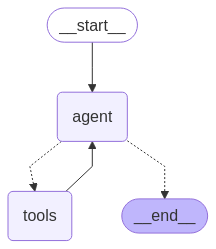

In [43]:


from typing import Annotated,Sequence, Literal, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph, START


def agent(state):
    messages = state["messages"]
    model = ChatOpenAI()
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}


def should_continue(state) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END


from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)

tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
)
workflow.add_edge("tools", "agent")

graph = workflow.compile()


from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)


In [44]:
graph.invoke(input={
    "messages": [HumanMessage(content="Who is the owner and what are the timings?")]
})


=========len---========== 2
=========len---========== 2


{'messages': [HumanMessage(content='Who is the owner and what are the timings?', additional_kwargs={}, response_metadata={}, id='aab1dad4-a96a-493e-935d-f56569fef437'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_o9NjePsao0ux6CvAAoK9sedX', 'function': {'arguments': '{"retiever_schema": {"query": "Owner of Peak Performance Gym"}}', 'name': 'retriever_tool_func'}, 'type': 'function'}, {'id': 'call_8FHpDP6cv1guXR9NKJyHa8eq', 'function': {'arguments': '{"retiever_schema": {"query": "Operating Hours of Peak Performance Gym"}}', 'name': 'retriever_tool_func'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 131, 'total_tokens': 200, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None,

In [45]:

graph.invoke(
    input={"messages": [HumanMessage(content="How will the weather be tommorrow?")]}
)


{'messages': [HumanMessage(content='How will the weather be tommorrow?', additional_kwargs={}, response_metadata={}, id='53b1bc42-b1f7-40a5-b31c-cca2e22efee8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_wvfrWPnzbMDw80zBzO2gZQj6', 'function': {'arguments': '{}', 'name': 'off_topic'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 130, 'total_tokens': 141, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BSJkFxFhfVt4RegOEU3gMJInB4ec3', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-8fc28f2c-ab7c-41a0-8920-b0b1c6b0b1b8-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 'call_wvfrWPnzbMDw80zBzO2gZQj6', 'type': 'tool_call'}], usage_metadata={'in